In [1]:
### Plot hereditary scores vs r^2

In [2]:
# Requirements

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.cluster import KMeans
from scipy.spatial.distance import pdist, squareform
import xgboost as xgb
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
import shap
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from scipy.stats import shapiro
from scipy.stats import pearsonr
import gc
from scipy.stats import linregress

ModuleNotFoundError: No module named 'pandas'

In [3]:
hereditary_scores_Mural = pd.read_csv("/Users/madisoncreach/Prediction_Project/pheno_data/Mural_2022/giac080_supplemental_files/SupplementalDataFileS3_PhenotypeMetaData.csv")

In [4]:
hereditary_scores = hereditary_scores_Mural.rename(columns={"TraitID" : "Phenotype", "EstimatedHeritability (SNP based narrow sense)" : "Heritability"})
hereditary_scores_index = hereditary_scores.set_index('Phenotype')
hereditary_scores_gwas = hereditary_scores_index[["Heritability", "PhenotypeGroup"]]

In [5]:
# read in genetic and expression rrblup r2 scores

r2_scores_snp_expression = pd.read_csv("/Users/madisoncreach/Prediction_Project/cv_fold_rrblup_exp_gen_r_scores.csv")
r2_scores_snp_expression_index = r2_scores_snp_expression.set_index("Phenotype")

In [6]:
merged_hereditary_snp_exp_r2 = pd.merge(hereditary_scores_gwas, r2_scores_snp_expression_index, left_index=True, right_index=True)

In [7]:
phenotype_groups = merged_hereditary_snp_exp_r2["PhenotypeGroup"].unique()
colors = plt.cm.tab10(range(len(phenotype_groups)))  # Use the "tab10" colormap
color_map = dict(zip(phenotype_groups, colors))

In [18]:
phenotype_to_group = dict(
    zip(
        merged_hereditary_snp_exp_r2.index,
        merged_hereditary_snp_exp_r2["PhenotypeGroup"]
    )
)

In [19]:
print(phenotype_to_group)

{'LastJuvenileLeaf_A': 'Vegetative', 'Anthesis_A': 'FloweringTime', 'Silking_A': 'FloweringTime', 'SMV7DAI_B': 'Disease', 'TasselLength1_C': 'Inflorescence', 'SpikeLength1_C': 'Inflorescence', 'BranchNumber1_C': 'Inflorescence', 'TasselWeight1_C': 'Inflorescence', 'BranchZoneLength_C': 'Inflorescence', 'BranchDensity_C': 'Inflorescence', 'Tassellength2_C': 'Inflorescence', 'SpikeLength2_C': 'Inflorescence', 'BranchNumber2_C': 'Inflorescence', 'TasselWeight2_C': 'Inflorescence', 'Compactness_C': 'Inflorescence', 'PerimeterLength_C': 'Inflorescence', 'SkeletonLength_C': 'Inflorescence', 'StalkDiameter_D': 'Vegetative', 'PlantHeight_D': 'Vegetative', 'VascularBundleDensity_D': 'Cellular/Biochemical', 'BulliformColNumber2_E': 'Cellular/Biochemical', 'BulliformColWidth2_E': 'Cellular/Biochemical', 'BulliformColNumber3_E': 'Cellular/Biochemical', 'BulliformColWidth3_E': 'Cellular/Biochemical', 'PlantHeight_G': 'Vegetative', 'Anthesis_G': 'FloweringTime', 'BiomassYield_G': 'Vegetative', 'Anth

In [8]:
markers = ['o', 's', 'D', '^', 'v', 'P', '*', 'X', '<', '>']  # Add more if needed

# Create a dictionary mapping each phenotype group to a unique marker
marker_map = {group: markers[i % len(markers)] for i, group in enumerate(phenotype_groups)}

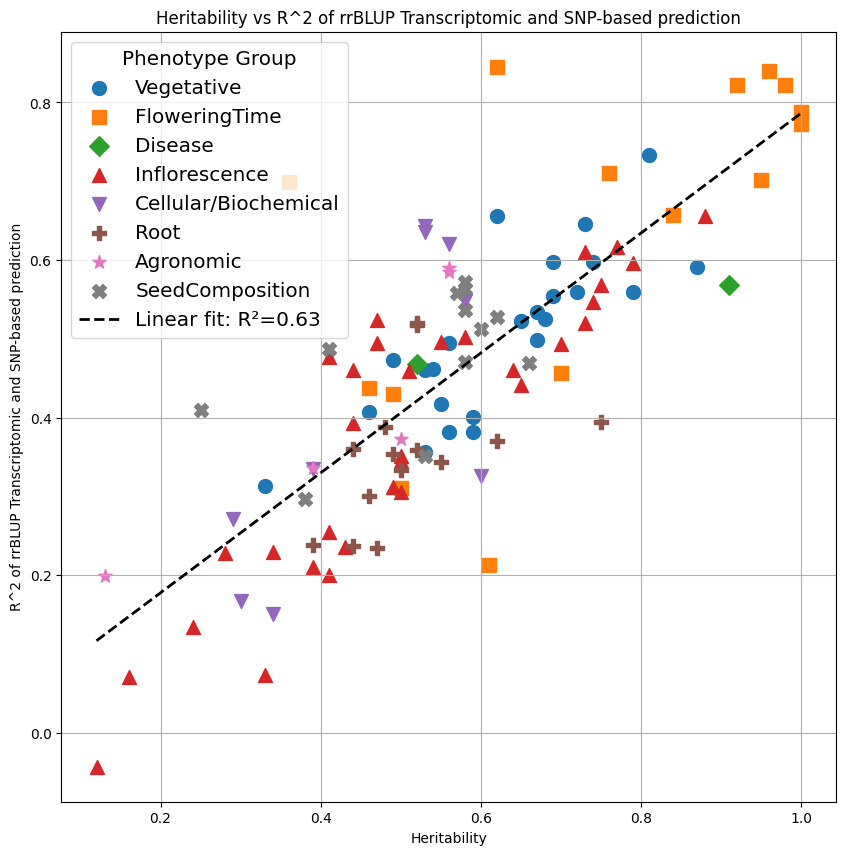

In [ ]:
plt.figure(figsize=(10, 10))
for group in phenotype_groups:
    subset = merged_hereditary_snp_exp_r2[merged_hereditary_snp_exp_r2["PhenotypeGroup"] == group]  # Filter by category
    plt.scatter(
        subset["Heritability"], 
        subset["R2_Score"], 
        color=color_map[group], 
        label=group, 
        s=100,  # Increase point size
        marker=marker_map[group]  # Assign unique marker shape
    )

x = merged_hereditary_snp_exp_r2["Heritability"]
y = merged_hereditary_snp_exp_r2["R2_Score"]

slope, intercept, r_value, p_value, std_err = linregress(x, y)
x_vals = np.array([x.min(), x.max()])
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, color='black', linestyle='--', linewidth=2, label=f'Linear fit: R²={r_value**2:.2f}, p={p_value}')

plt.title('Heritability vs R^2 of rrBLUP Transcriptomic and SNP-based prediction')
plt.xlabel('Heritability')
plt.ylabel('R^2 of rrBLUP Transcriptomic and SNP-based prediction')
plt.legend(title="Phenotype Group", loc='upper left', fontsize='x-large', title_fontsize='x-large')
plt.grid(True)
plt.rcParams['pdf.fonttype'] = 42
#plt.savefig("/Users/madisoncreach/Prediction_Project/Figures/Fig3_A.pdf")

In [10]:
# read in genetic rrblup r2 scores

r2_scores_snp = pd.read_csv("/Users/madisoncreach/Prediction_Project/cv_fold_rrblup_gen_r_scores.csv")
r2_scores_snp_index = r2_scores_snp.set_index("Phenotype")

In [11]:
merged_hereditary_snp_r2 = pd.merge(hereditary_scores_gwas, r2_scores_snp_index, left_index=True, right_index=True)

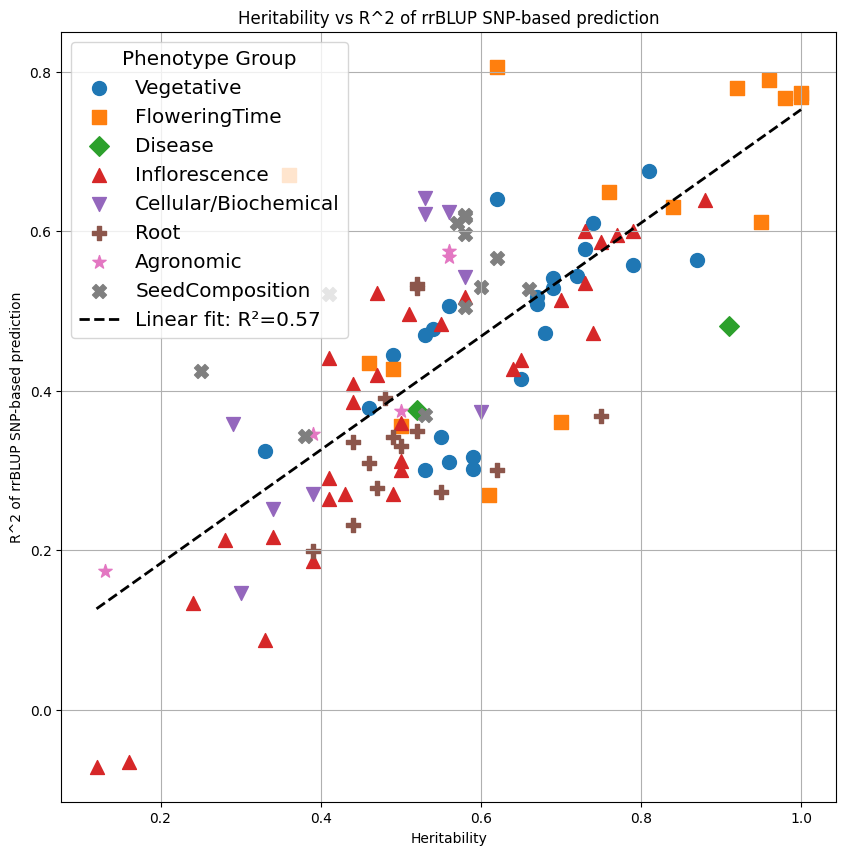

In [12]:
plt.figure(figsize=(10, 10))
for group in phenotype_groups:
    subset = merged_hereditary_snp_r2[merged_hereditary_snp_r2["PhenotypeGroup"] == group]  # Filter by category
    plt.scatter(
        subset["Heritability"], 
        subset["R2_Score"], 
        color=color_map[group], 
        label=group, 
        s=100,  # Increase point size
        marker=marker_map[group]  # Assign unique marker shape
    )

x = merged_hereditary_snp_r2["Heritability"]
y = merged_hereditary_snp_r2["R2_Score"]

slope, intercept, r_value, p_value, std_err = linregress(x, y)
x_vals = np.array([x.min(), x.max()])
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, color='black', linestyle='--', linewidth=2, label=f'Linear fit: R²={r_value**2:.2f}')

plt.title('Heritability vs R^2 of rrBLUP SNP-based prediction')
plt.xlabel('Heritability')
plt.ylabel('R^2 of rrBLUP SNP-based prediction')
plt.legend(title="Phenotype Group", loc='upper left', fontsize='x-large', title_fontsize='x-large')
plt.grid(True)
plt.rcParams['pdf.fonttype'] = 42
#plt.savefig("/Users/madisoncreach/Prediction_Project/Heritability_vs_R2.pdf")

In [13]:
# read in expression rrblup r2 scores

r2_scores_expression = pd.read_csv("/Users/madisoncreach/Prediction_Project/cv_fold_rrblup_exp_r_scores.csv")
r2_scores_expression_index = r2_scores_expression.set_index("Phenotype")

In [14]:
merged_hereditary_expression_r2 = pd.merge(hereditary_scores_gwas, r2_scores_expression_index, left_index=True, right_index=True)

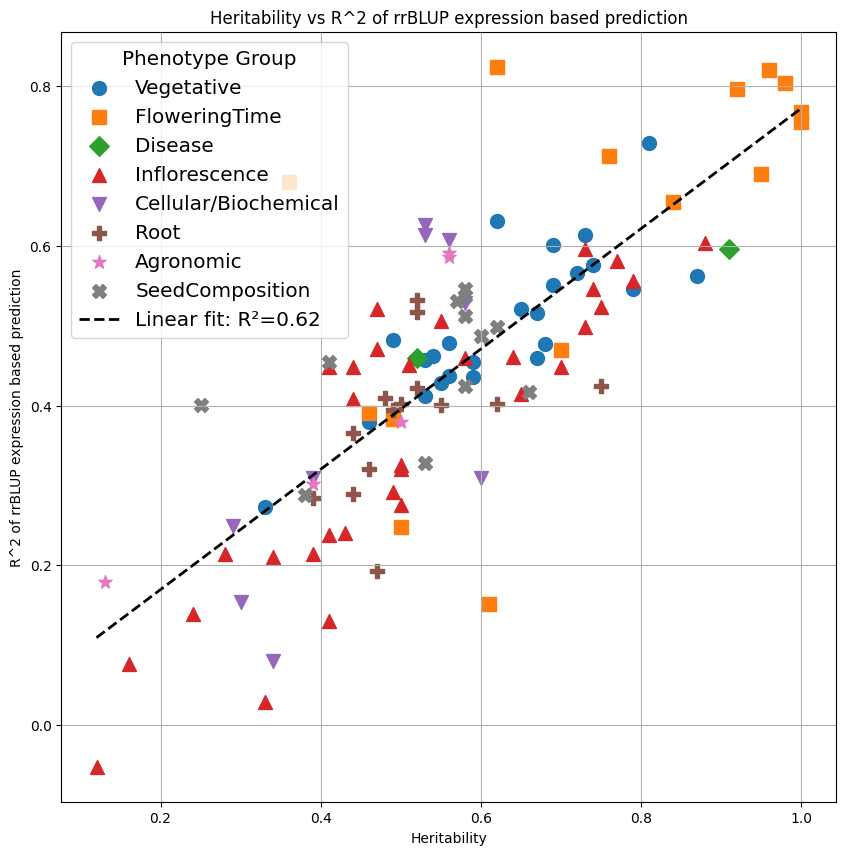

In [15]:
plt.figure(figsize=(10, 10))
for group in phenotype_groups:
    subset = merged_hereditary_expression_r2[merged_hereditary_expression_r2["PhenotypeGroup"] == group]  # Filter by category
    plt.scatter(
        subset["Heritability"], 
        subset["R2_Score"], 
        color=color_map[group], 
        label=group, 
        s=100,  # Increase point size
        marker=marker_map[group]  # Assign unique marker shape
    )

x = merged_hereditary_expression_r2["Heritability"]
y = merged_hereditary_expression_r2["R2_Score"]

slope, intercept, r_value, p_value, std_err = linregress(x, y)
x_vals = np.array([x.min(), x.max()])
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, color='black', linestyle='--', linewidth=2, label=f'Linear fit: R²={r_value**2:.2f}')

plt.title('Heritability vs R^2 of rrBLUP expression based prediction')
plt.xlabel('Heritability')
plt.ylabel('R^2 of rrBLUP expression based prediction')
plt.legend(title="Phenotype Group", loc='upper left', fontsize='x-large', title_fontsize='x-large')
plt.grid(True)
plt.rcParams['pdf.fonttype'] = 42
#plt.savefig("/Users/madisoncreach/Prediction_Project/Heritability_vs_R2.pdf")